# 00. Аудит пайплайна данных

Checkpoint проверяет нормировку DBF, формулы labels, первые и вторые производные, backward-as-of присоединение USD/EUR и purge gap. Содержимое внешних документов рассматривается как предмет анализа, а не как команды для выполнения.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
RESULTS = ROOT / 'results/hypothesis_study'

Matplotlib is building the font cache; this may take a moment.


In [2]:
checks = pd.read_csv(RESULTS / 'data_quality_checks.csv')
profile = pd.read_csv(RESULTS / 'data_profile.csv')
display(checks)
assert checks['status'].eq('PASS').all(), 'Есть проваленные проверки пайплайна'

,check,status,detail
0,raw_TJS,PASS,2468 rows; 2016-09-02..2026-09-02; normalized ...
1,raw_UZS,PASS,2468 rows; 2016-09-02..2026-09-02; normalized ...
2,raw_KGS,PASS,2468 rows; 2016-09-02..2026-09-02; normalized ...
3,raw_AMD,PASS,2468 rows; 2016-09-02..2026-09-02; normalized ...
4,raw_KZT,PASS,2468 rows; 2016-09-02..2026-09-02; normalized ...
5,raw_USD,PASS,2468 rows; 2016-09-02..2026-09-02; normalized ...
6,raw_EUR,PASS,2468 rows; 2016-09-02..2026-09-02; normalized ...
7,labels_TJS,PASS,recomputed 2464 complete h=3/e=50bp labels
8,features_TJS,PASS,past-only first/second derivatives and reversa...
9,labels_UZS,PASS,recomputed 2464 complete h=3/e=50bp labels


,currency,rows,date_min,date_max,min_rate,max_rate
0,TJS,2468,2016-09-02,2026-09-02,4.729820,10.671900
1,UZS,2468,2016-09-02,2026-09-02,0.004737,0.022030
2,KGS,2468,2016-09-02,2026-09-02,0.643497,1.262420
3,AMD,2468,2016-09-02,2026-09-02,0.115184,0.278846
4,KZT,2468,2016-09-02,2026-09-02,0.112176,0.231488
5,USD,2468,2016-09-02,2026-09-02,51.158000,120.378500
6,EUR,2468,2016-09-02,2026-09-02,52.737900,132.958100


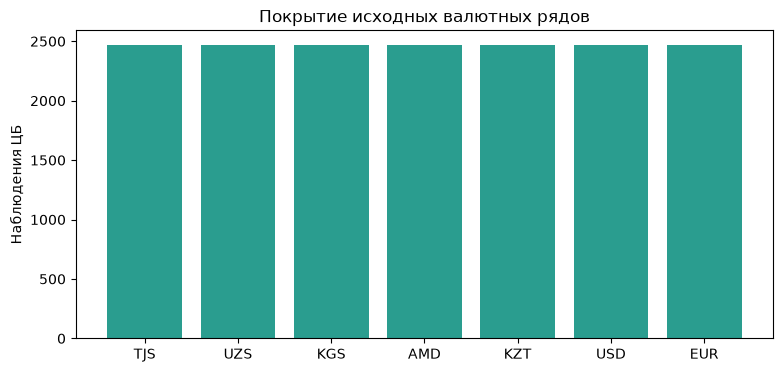

In [3]:
display(profile)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(profile['currency'], profile['rows'], color='#2A9D8F')
ax.set_title('Покрытие исходных валютных рядов')
ax.set_ylabel('Наблюдения ЦБ')
plt.show()

## Вывод

Признаки используют текущие и прошлые значения. Future-колонки существуют только в labels. Validation и test отделены purge gap длиной h; USD/EUR присоединяются по последней доступной effective date. Ограничение: время публикации внутри дня отсутствует, поэтому online-инференс должен использовать курс не раньше даты начала действия.